<a href="https://colab.research.google.com/github/RosarioH10062002/M2_master_thesis/blob/main/EEG_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LIBRARIES**

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.interpolate import interp1d
drive.mount('/content/drive')
try:
  from emgio.importers.xdf import summarize_xdf as emgio_summarize_xdf
except:
  !pip install emgio
  from emgio.importers.xdf import summarize_xdf as emgio_summarize_xdf
try:
  import pyxdf
except:
  !pip install pyxdf
  import pyxdf

try:
  import mne
except:
  !pip install mne
from matplotlib import colors
import plotly.express as px
import matplotlib.image as mpimg
import inspect
from scipy.stats import zscore
# To open a google sheets
#from google.colab import auth
#auth.authenticate_user()

#import gspread
#from google.auth import default
#creds, _ = default()
#gc = gspread.authorize(creds)
from collections import Counter

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOAD DATA**

In [2]:
ROOT_PATH = "/content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase"
ROOT_RAW_PATH = "/content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy"
ROOT_RAW_TRIMMED_PATH = "/content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy_trimmed"
ROOT_DATASETS = "/content/drive/My Drive/M2_Project_Master/Data/Participants data/Important_datasets"

In [3]:
list_total_xdf = []
for f in Path(ROOT_PATH).rglob(f"*.xdf"):
  list_total_xdf.append(f)
print(len(list_total_xdf))
  #print(f)

99


In [4]:
#@title Get data
def get_subjects():
  return [2,5,6,8,10,13]
def get_channel_names_bitbrain():
  return ["AF7", "Fp1", "Fp2", "AF8", "P7", "O1", "O2", "P8"]
def get_channel_names_openbci():
  return ["Fp1", "Fp2", "C3", "C4", "O1", "O2", "P7", "P8"]

In [5]:
def get_list_xdf(id):
  list_dir = []
  phases = []
  date = []
  for f in Path(ROOT_PATH).rglob(f"ID{id}/*.xdf"):
    if f.name.endswith("A.xdf"):
      list_dir.append(f)
      phases.append("A")
    elif f.name.endswith("B.xdf"):
      list_dir.append(f)
      phases.append("B")
    #print(date)
    date.append(str(f)[-14:-6])
  #print(f"Dir: {len(list_dir)}, Date: {len(date)}, Phase: {len(phases)}")
  #print(date)
  #return 0
  return pd.DataFrame({"Dir": list_dir, "Date": date, "Phase": phases})


print(f"XDF TOTAL SESSIONS: ID2 = {len(get_list_xdf(id = 2))},ID5 = {len(get_list_xdf(id = 5))}, ID6 = {len(get_list_xdf(id = 6))}, ID8 = {len(get_list_xdf(id = 8))}, ID10 = {len(get_list_xdf(id = 10))}, ID13 = {len(get_list_xdf(id = 13))}")
get_list_xdf(id = 2)

XDF TOTAL SESSIONS: ID2 = 16,ID5 = 13, ID6 = 13, ID8 = 19, ID10 = 19, ID13 = 19


,Dir,Date,Phase
0,/content/drive/My Drive/M2_Project_Master/Data...,13-04-26,A
1,/content/drive/My Drive/M2_Project_Master/Data...,17-04-26,A
2,/content/drive/My Drive/M2_Project_Master/Data...,21-04-26,A
3,/content/drive/My Drive/M2_Project_Master/Data...,23-04-26,A
4,/content/drive/My Drive/M2_Project_Master/Data...,11-05-26,A
5,/content/drive/My Drive/M2_Project_Master/Data...,19-05-26,A
6,/content/drive/My Drive/M2_Project_Master/Data...,22-05-26,A
7,/content/drive/My Drive/M2_Project_Master/Data...,27-05-26,A
8,/content/drive/My Drive/M2_Project_Master/Data...,04-06-26,B
9,/content/drive/My Drive/M2_Project_Master/Data...,08-06-26,B


In [6]:
def get_summary_xdf(xdf_file):
  summary = emgio_summarize_xdf(xdf_file)
  print(summary)
xdf_file = get_list_xdf(id = 2)["Dir"].iloc[8]
get_summary_xdf(xdf_file)

XDF File: /content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase/W8/ID2/EEG_Behavior_04-06-26_B.xdf
Number of streams: 9

Stream 1: Markers
  Type: Markers
  Channels: 1
  Nominal srate: 0.0 Hz
  Samples: 0
  Duration: 0.00 s
  Format: string
  Channel labels: Ch1

Stream 7: eeg8ch_quality
  Type: Markers
  Channels: 8
  Nominal srate: 0.0 Hz
  Effective srate: 0.40 Hz
  Samples: 20
  Duration: 50.00 s
  Format: int16
  Channel labels: Ch1, Ch2, Ch3, Ch4, Ch5, ... (+3 more)

Stream 3: Psychopy_markers
  Type: Markers
  Channels: 1
  Nominal srate: 0.0 Hz
  Effective srate: 0.53 Hz
  Samples: 5
  Duration: 9.42 s
  Format: int32
  Channel labels: Ch1

Stream 8: Sync
  Type: Markers
  Channels: 1
  Nominal srate: 0.0 Hz
  Effective srate: 0.10 Hz
  Samples: 4
  Duration: 40.03 s
  Format: int16
  Channel labels: Ch1

Stream 5: Start_Stop
  Type: Markers
  Channels: 1
  Nominal srate: 0.0 Hz
  Samples: 0
  Duration: 0.00 s
  Format: string
  Channel labels: Ch1

Str

In [7]:
def print_summary():
  list_participants = get_subjects()
  for s in list_participants:
    list_xdf = get_list_xdf(id = s)
    list_A = len(list_xdf[list_xdf["Phase"] == "A"])
    list_B = len(list_xdf[list_xdf["Phase"] == "B"])
    print(f"ID:{s}, Sessions A: {list_A}, Sessions B: {list_B}")
print_summary()

ID:2, Sessions A: 8, Sessions B: 8
ID:5, Sessions A: 7, Sessions B: 6
ID:6, Sessions A: 3, Sessions B: 10
ID:8, Sessions A: 10, Sessions B: 9
ID:10, Sessions A: 9, Sessions B: 10
ID:13, Sessions A: 7, Sessions B: 12


In [8]:
def convert_mne_object():
  mne_object = True
  return mne_object

In [9]:
def sampling_rates(stream):
    nominal_sr = float(stream["info"]["nominal_srate"][0])

    ts = stream["time_stamps"]
    duration = ts[-1] - ts[0]
    n_samples = len(ts)

    effective_sr = n_samples / duration

    return nominal_sr, effective_sr

In [10]:
def reconstruct_to_nominal_fs(stream,target_fs=250):

    data = stream["time_series"]
    ts = stream["time_stamps"]

    t_new = np.arange(ts[0],ts[-1],1/target_fs)

    data_new = np.zeros((len(t_new),data.shape[1]))

    for ch in range(data.shape[1]):
        f = interp1d(
            ts,
            data[:,ch],
            kind="previous",
            bounds_error=False,
            fill_value="extrapolate"
        )

        data_new[:,ch] = f(t_new)

    #print(f"Original samples: {data.shape[0]}")
    #print(f"New samples: {data_new.shape[0]}")
    #print(f"Duration: {ts[-1]-ts[0]:.2f} s")
    #print(f"Fs: {target_fs} Hz")

    return data_new,t_new

In [11]:
def get_retrieve_streams(data,id):

    xdf_file = data["Dir"]
    date = str(data["Date"])
    phase = str(data["Phase"])
    company = []

    streams,header = pyxdf.load_xdf(xdf_file)

    eeg_df = None
    markers_df = None

    for i,stream in enumerate(streams):

        print(i,stream["info"]["name"])

        if stream["info"]["name"][0] == "Psychopy_markers":

            markers_df = pd.DataFrame({"marker":[m[0] for m in stream["time_series"]],"timestamp":stream["time_stamps"]})

        if stream["info"]["name"][0] == "OpenBCI_EEG":
            #print(stream["info"])

            nominal_sr,effective_sr = sampling_rates(stream)
            print( f"Effective sampling rate: {effective_sr:.3f} Hz, Nominal sampling rate: {nominal_sr:.3f} Hz")
            data_250,t_250 = reconstruct_to_nominal_fs(stream)
            eeg_df = pd.DataFrame(data_250,columns=get_channel_names_openbci())
            eeg_df["timestamp"] = t_250
            company.append("OpenBCI_EEG")
            eeg_df.to_csv(Path(ROOT_RAW_PATH, f"ID{id}", f"ID{id}_{date}_{phase}_OpenBCI_EEG_eeg.csv"),index=False)

        if stream["info"]["name"][0] == "eeg8ch_eeg":
            nominal_sr,effective_sr = sampling_rates(stream)
            print(f"Effective sampling rate: {effective_sr:.3f} Hz, Nominal sampling rate: {nominal_sr:.3f} Hz")
            eeg_df = pd.DataFrame(stream["time_series"][:,:8],columns=get_channel_names_bitbrain())
            eeg_df["timestamp"] = stream["time_stamps"]
            company.append("BitBrain_EEG")
            eeg_df.to_csv(Path(ROOT_RAW_PATH, f"ID{id}", f"ID{id}_{date}_{phase}_BitBrain_EEG_eeg.csv"),index=False)

    if markers_df is not None:
        markers_df.to_csv(Path(ROOT_RAW_PATH, f"ID{id}", f"ID{id}_{date}_{phase}_markers.csv"),index=False)

    return eeg_df,markers_df

In [12]:
#@title Save raw data
list_participants = get_subjects()
for id in list_participants:
  df = get_list_xdf(id=id)
  for n in range(df.shape[0]):
    eeg_df,markers_df = get_retrieve_streams(data=df.loc[n,:], id=id)


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 862.462 Hz, Nominal sampling rate: 250.000 Hz


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 816.082 Hz, Nominal sampling rate: 250.000 Hz


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 867.956 Hz, Nominal sampling rate: 250.000 Hz


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 807.779 Hz, Nominal sampling rate: 250.000 Hz
0 ['Sync']
1 ['eeg8ch_imu']
2 ['Start_Stop']
3 ['eeg8ch_quality']
4 ['Psychopy_markers']
5 ['Markers']
6 ['eeg8ch_din']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.989 Hz, Nominal sampling rate: 256.000 Hz
8 ['eeg8ch_photodiode']
0 ['eeg8ch_imu']
1 ['Start_Stop']
2 ['Psychopy_markers']
3 ['Markers']
4 ['Sync']
5 ['eeg8ch_quality']
6 ['eeg8ch_photodiode']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.973 Hz, Nominal sampling rate: 256.000 Hz
8 ['eeg8ch_din']
0 ['Psychopy_markers']
1 ['eeg8ch_imu']
2 ['Start_Stop']
3 ['Sync']
4 ['eeg8ch_quality']
5 ['eeg8ch_photodiode']
6 ['Markers']
7 ['eeg8ch_din']
8 ['eeg8ch_eeg']
Effective sampling rate: 255.990 Hz, Nominal sampling rate: 256.000 Hz
0 ['eeg8ch_imu']
1 ['Markers']
2 ['Sync']
3 ['eeg8ch_photodiode']
4 ['Start_Stop']
5 ['Psychopy_markers']
6 ['eeg8ch_quality']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.991 Hz, Nominal sam

0 ['OpenBCI_EEG']
Effective sampling rate: 861.827 Hz, Nominal sampling rate: 250.000 Hz
1 ['Psychopy_markers']


...

0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 867.050 Hz, Nominal sampling rate: 250.000 Hz


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 806.449 Hz, Nominal sampling rate: 250.000 Hz
2 ['Psychopy_markers']


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 868.170 Hz, Nominal sampling rate: 250.000 Hz


0 ['Psychopy_markers']
1 ['OpenBCI_EEG']
Effective sampling rate: 880.738 Hz, Nominal sampling rate: 250.000 Hz
0 ['eeg8ch_imu']
1 ['Sync']
2 ['Psychopy_markers']
3 ['eeg8ch_quality']
4 ['Markers']
5 ['Start_Stop']
6 ['eeg8ch_photodiode']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.989 Hz, Nominal sampling rate: 256.000 Hz
8 ['eeg8ch_din']
0 ['Psychopy_markers']
1 ['eeg8ch_quality']
2 ['Markers']
3 ['eeg8ch_imu']
4 ['Start_Stop']
5 ['Sync']
6 ['eeg8ch_photodiode']
7 ['eeg8ch_din']
8 ['eeg8ch_eeg']
Effective sampling rate: 255.990 Hz, Nominal sampling rate: 256.000 Hz
0 ['Sync']
1 ['Psychopy_markers']
2 ['eeg8ch_quality']
3 ['eeg8ch_imu']
4 ['Start_Stop']
5 ['Markers']
6 ['eeg8ch_din']
7 ['eeg8ch_photodiode']
8 ['eeg8ch_eeg']
Effective sampling rate: 255.988 Hz, Nominal sampling rate: 256.000 Hz
0 ['eeg8ch_quality']
1 ['Psychopy_markers']
2 ['eeg8ch_imu']
3 ['Markers']
4 ['Sync']
5 ['eeg8ch_photodiode']
6 ['Start_Stop']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.988 Hz, Nominal sam

0 ['eeg8ch_imu']
1 ['Start_Stop']
2 ['Sync']
3 ['eeg8ch_quality']
4 ['Markers']
5 ['Psychopy_markers']
6 ['eeg8ch_din']
7 ['eeg8ch_eeg']
Effective sampling rate: 255.989 Hz, Nominal sampling rate: 256.000 Hz
8 ['eeg8ch_photodiode']


In [13]:
#@title Get EEG and Psychopy path df
def get_df_sessions(id):
  label = []
  sessions_eeg = []
  markers_eeg = []
  date = []
  company = []
  for path in Path(ROOT_RAW_PATH).rglob(f"ID{id}/*.csv"):
    if path.name.endswith("eeg.csv"):
      sessions_eeg.append(path)
      index = path.name.find("26_")
      date_str= path.name[index-6:index+2]
      date.append(date_str)
      if path.name.find("A") != -1:
        label_str = "A"
        label.append("A")
      elif path.name.find("B")!= -1:
        label_str = "B"
        label.append("B")
      else:
        print(f"{path.name} Unknown label")

      if path.name.find("BitBrain_EEG") !=-1:
        company.append("BitBrain_EEG")
      elif path.name.find("OpenBCI_EEG_eeg") !=-1:
        company.append("OpenBCI_EEG_eeg")
      else:
        print(f"Unknown company")

      marker_path = next(Path(ROOT_RAW_PATH).rglob(f"ID{id}/ID{id}_{date_str}_{label_str}_markers.csv"),None)
      markers_eeg.append(marker_path)
  #print(date)
  return pd.DataFrame({"RAW EEG": sessions_eeg, "PSYCHOPY": markers_eeg, "LABEL": label, "DATE": date, "COMPANY": company})
id = 2
get_df_sessions(id)
#print(get_df_sessions(id)["RAW EEG"].iloc[5])

,RAW EEG,PSYCHOPY,LABEL,DATE,COMPANY
0,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,13-04-26,OpenBCI_EEG_eeg
1,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,21-04-26,OpenBCI_EEG_eeg
2,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,23-04-26,OpenBCI_EEG_eeg
3,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,11-05-26,BitBrain_EEG
4,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,19-05-26,BitBrain_EEG
5,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,22-05-26,BitBrain_EEG
6,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,27-05-26,BitBrain_EEG
7,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,08-06-26,BitBrain_EEG
8,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,10-06-26,BitBrain_EEG
9,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,12-06-26,BitBrain_EEG


In [14]:
#@title Why I discarted some EEG sessions from ID2, ID8 and partially reconstruct ID10
def get_usable_df_check_timestamps(id):
  eeg_trim_path = []
  print(f"Timestamps for ID {id}__")
  df = get_df_sessions(id)
  usable_df = df.copy()
  bad_rows = set()
  marker_start = None
  marker_end = None
  for index, row in df.iterrows():
    date = str(row["DATE"])
    phase = str(row["LABEL"])
    company = str(row["COMPANY"])
    try:
      markers_df = pd.read_csv(row["PSYCHOPY"])
    except ValueError:
      print(f"None in Psychopy Session {row["DATE"]}")
      #usable_df = usable_df.drop(index)
      bad_rows.add(index)
      continue
    try:
      index_start = markers_df[markers_df["marker"] == 90].index[0]
      marker_start = markers_df[markers_df["marker"] == 90]["timestamp"].iloc[0]
    except IndexError:
      print(f"IndexError Marker Start Session {row["DATE"]}")
      bad_rows.add(index)
      continue
    try:
      index_end = markers_df[markers_df["marker"] == 93].index[0]
      marker_end = markers_df[markers_df["marker"] == 93]["timestamp"].iloc[0]
    except IndexError:
      print(f"IndexError Marker End Session {row["DATE"]}")
      bad_rows.add(index)
      continue

    #print(f"start: {marker_start}, end: {marker_end}")
    eeg_df = pd.read_csv(row["RAW EEG"])
    idx_start = np.argmin(
    np.abs(
        eeg_df["timestamp"] - marker_start
        )
    )

    idx_end = np.argmin(
        np.abs(
            eeg_df["timestamp"] - marker_end
        )
    )


    if row["COMPANY"] == "OpenBCI_EEG_eeg":
      fs = 250

    else:
      fs = 256
    buffer = int(2 * fs)

    idx_start = max(0, idx_start - buffer)

    idx_end = min(len(eeg_df)-1, idx_end + buffer)
    eeg_trim = eeg_df.iloc[idx_start:idx_end+1]
    eeg_trim.to_csv(Path(ROOT_RAW_TRIMMED_PATH, f"ID{id}",f"ID{id}_{date}_{phase}_{company}.csv"), index = False)
    eeg_trim_path.append(str(Path(ROOT_RAW_TRIMMED_PATH, f"ID{id}",f"ID{id}_{date}_{phase}_{company}.csv")))
    markers_trim = markers_df.iloc[index_start:index_end+1].copy()
    eeg_trim_start = eeg_trim["timestamp"].iloc[0]
    markers_trim["onset"] = (markers_trim["timestamp"] - eeg_trim_start)

    markers_trim.to_csv(Path(ROOT_RAW_TRIMMED_PATH,f"ID{id}",f"ID{id}_{date}_{phase}_markers.csv"),index=False)

  usable_df = df.drop(index=list(bad_rows)).copy()

  usable_df = usable_df.reset_index(drop=True)

  usable_df.insert(1,"TRIMMED RAW EEG",eeg_trim_path)
  #display(usable_df)
  return usable_df

final_dataset = []
for s in get_subjects():
  usable_df = get_usable_df_check_timestamps(id = s)
  usable_df["ID"] = s
  final_dataset.append(usable_df)
  #display(usable_df)
#final_df = pd.concat(final_dataset,ignore_index=True)
#final_df.to_csv(Path(ROOT_DATASETS, "all_ids.csv"), index = False)
#display(final_df)
final_df = pd.concat(final_dataset, ignore_index=True)

all_ids_path = Path(ROOT_DATASETS, "all_ids.csv")

if all_ids_path.exists():

    old_df = pd.read_csv(all_ids_path)

    cols_to_keep = [
        "ID",
        "DATE",
        "LABEL",
        "COMPANY",
        "ICA PATH",
        "ICA EXCLUDE",
        "BAD CHANNELS"
    ]

    existing_cols = [
        c for c in cols_to_keep
        if c in old_df.columns
    ]

    final_df = final_df.merge(
        old_df[existing_cols],
        on=["ID", "DATE", "LABEL", "COMPANY"],
        how="left"
    )

final_df.to_csv(all_ids_path, index=False)

display(final_df)
#get_usable_df_check_timestamps(id = 8)
#get_usable_df_check_timestamps(id = 10)
#display(eeg_df)
#display(markers_df)

Timestamps for ID 2__
IndexError Marker Start Session 17-04-26
IndexError Marker End Session 04-06-26
Timestamps for ID 5__
Timestamps for ID 6__
Timestamps for ID 8__
None in Psychopy Session 26-05-26
Timestamps for ID 10__
IndexError Marker Start Session 16-04-26
Timestamps for ID 13__


,RAW EEG,TRIMMED RAW EEG,PSYCHOPY,LABEL,DATE,COMPANY,ID,ICA PATH,ICA EXCLUDE,BAD CHANNELS
0,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,13-04-26,OpenBCI_EEG_eeg,2,NaN,NaN,NaN
1,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,21-04-26,OpenBCI_EEG_eeg,2,NaN,NaN,NaN
2,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,23-04-26,OpenBCI_EEG_eeg,2,NaN,NaN,NaN
3,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,11-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,1.0,NaN
4,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,19-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
90,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,15-06-26,BitBrain_EEG,13,NaN,NaN,NaN
91,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,17-06-26,BitBrain_EEG,13,NaN,NaN,NaN
92,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,19-06-26,BitBrain_EEG,13,NaN,NaN,NaN
93,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,22-06-26,BitBrain_EEG,13,NaN,NaN,NaN


In [15]:
raw_markers_path = final_df["PSYCHOPY"][54]
raw_markers_path

PosixPath('/content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy/ID8/ID8_17-06-26_B_markers.csv')

In [16]:
raw_markers = pd.read_csv(final_df["PSYCHOPY"][54])
raw_markers["onset"] = raw_markers["timestamp"]-raw_markers["timestamp"][0]
raw_markers_b = raw_markers.loc[(raw_markers["marker"] == 90)  | (raw_markers["marker"] == 91) | (raw_markers["marker"] == 92) | (raw_markers["marker"] == 93) | (raw_markers["marker"] == 1003)].copy()
display(raw_markers_b.head(4))


,marker,timestamp,onset
0,90,17901.039618,0.000000
4,1003,17961.039353,59.999735
6,91,18021.022570,119.982952
7,1003,18021.022577,119.982959


In [17]:
raw_markers = raw_markers.loc[(raw_markers["marker"] == 1) |(raw_markers["marker"] == 2)].loc[0:89,:].copy()
raw_markers["dt"] = raw_markers["onset"].diff()
display(raw_markers.head(5))

,marker,timestamp,onset,dt
20,2,18188.176569,287.136951,NaN
22,2,18189.183316,288.143698,1.006746
24,2,18190.167606,289.127988,0.984291
26,2,18191.183620,290.144002,1.016014
28,2,18192.200477,291.160858,1.016856


In [18]:
print(raw_markers["dt"].mean())
print(raw_markers["dt"].std())

1.015511634922134
0.005564780515979889


In [19]:
raw_markers_c = raw_markers.loc[(raw_markers["marker"] == 101)].loc[0:89,:].copy()
display(raw_markers_c.head(5))

,marker,timestamp,onset,dt


In [20]:
#@title To check the markers
raw_eeg = pd.read_csv(final_df["RAW EEG"][54])

<class 'numpy.ndarray'>


,AF7,Fp1,Fp2,AF8,P7,O1,O2,P8
0,-0.000456,0.017112,0.034280,0.002677,0.009943,0.040109,0.035785,0.031901
1,-0.000449,0.017120,0.034282,0.002682,0.009945,0.040105,0.035779,0.031901
2,-0.000450,0.017115,0.034274,0.002678,0.009950,0.040103,0.035774,0.031897
3,-0.000452,0.017111,0.034275,0.002677,0.009951,0.040101,0.035770,0.031894
4,-0.000447,0.017115,0.034286,0.002683,0.009950,0.040103,0.035765,0.031892
...,...,...,...,...,...,...,...,...
369643,-0.026919,0.000671,0.022732,-0.019004,-0.034043,-0.001700,0.001376,0.002679
369644,-0.026920,0.000669,0.022733,-0.019001,-0.034036,-0.001702,0.001378,0.002680
369645,-0.026923,0.000665,0.022731,-0.019004,-0.034035,-0.001702,0.001383,0.002672
369646,-0.026924,0.000666,0.022734,-0.019006,-0.034053,-0.001698,0.001397,0.002673


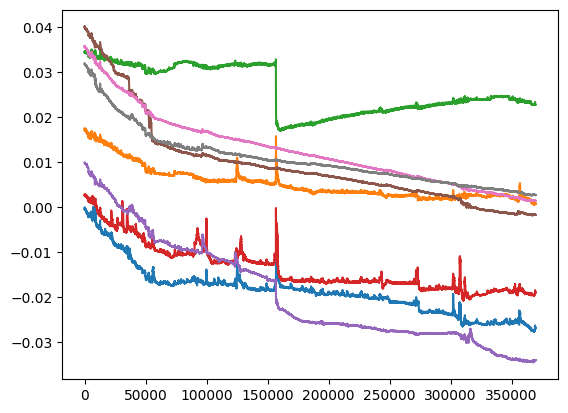

In [21]:
#@title To visualize Raw EEG
raw_eeg = pd.read_csv(final_df["RAW EEG"][54])
columns_channels=raw_eeg.columns[raw_eeg.columns != "timestamp"]
raw_eeg= raw_eeg[columns_channels].to_numpy().T *1e-6
print(type(raw_eeg))
raw_eeg_df = pd.DataFrame(raw_eeg.T)
raw_eeg_df.columns = columns_channels
display(raw_eeg_df)
#channels = ["AF7", "Fp1", "Fp2", "AF8", "P7", "O1", "O2", "P8"]
#print(raw_eeg_df.describe())
for ch in columns_channels:
    signal_v = raw_eeg_df[ch]
    plt.plot(signal_v)

In [22]:
def csv_to_raw(data,id):

    eeg_path = data["TRIMMED RAW EEG"]
    #eeg_path = data["RAW EEG"]
    markers_path = data["PSYCHOPY"]
    date = str(data["DATE"])
    phase = str(data["LABEL"])

    eeg_df = pd.read_csv(eeg_path)
    markers_df = pd.read_csv(markers_path)

    marker_start = markers_df[markers_df["marker"] == 90]["timestamp"]
    marker_end = markers_df[markers_df["marker"] == 93]["timestamp"]

    new_eeg_df = eeg_df["timestamp"]

    if data["COMPANY"] == "BitBrain_EEG":
      ch_names = get_channel_names_bitbrain()
      sfreq = 256
    else:
        ch_names = get_channel_names_openbci()
        sfreq = 250

    signal = eeg_df[ch_names].to_numpy() *1e-6

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")

    raw = mne.io.RawArray(signal.T, info)

    raw.set_montage( "standard_1020", on_missing="ignore")

    #raw.save(Path(ROOT_RAW_PATH, f"ID{id}", f"ID{id}_{date}_{phase}_raw.fif"), overwrite=True)
    raw.save(Path(ROOT_RAW_TRIMMED_PATH, f"ID{id}", f"ID{id}_{date}_{phase}_raw.fif"), overwrite=True)


    return raw

#**MNE DATA**

In [23]:
#@title To create and save the MNE object
for id in get_subjects():
  df = get_usable_df_check_timestamps(id =id)
  for _,row in df.iterrows():
    csv_to_raw(data = row, id = id)

Timestamps for ID 2__
IndexError Marker Start Session 17-04-26
IndexError Marker End Session 04-06-26
Creating RawArray with float64 data, n_channels=8, n_times=258020
    Range : 0 ... 258019 =      0.000 ...  1032.076 secs
Ready.
Overwriting existing file.
Writing /content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy_trimmed/ID2/ID2_13-04-26_A_raw.fif
Overwriting existing file.
Closing /content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy_trimmed/ID2/ID2_13-04-26_A_raw.fif
[done]
Creating RawArray with float64 data, n_channels=8, n_times=232588
    Range : 0 ... 232587 =      0.000 ...   930.348 secs
Ready.
Overwriting existing file.
Writing /content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy_trimmed/ID2/ID2_21-04-26_A_raw.fif
Overwriting existing file.
Closing /content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy_trimmed/ID2/ID2_21-04-26_A_raw.fif
[do

Opening raw data file /content/drive/My Drive/M2_Project_Master/Data/Participants data/Raw_data_eeg_psychopy/ID6/ID6_13-04-26_A_raw.fif...
    Range : 0 ... 254324 =      0.000 ...  1017.296 secs
Ready.
Reading 0 ... 254324  =      0.000 ...  1017.296 secs...


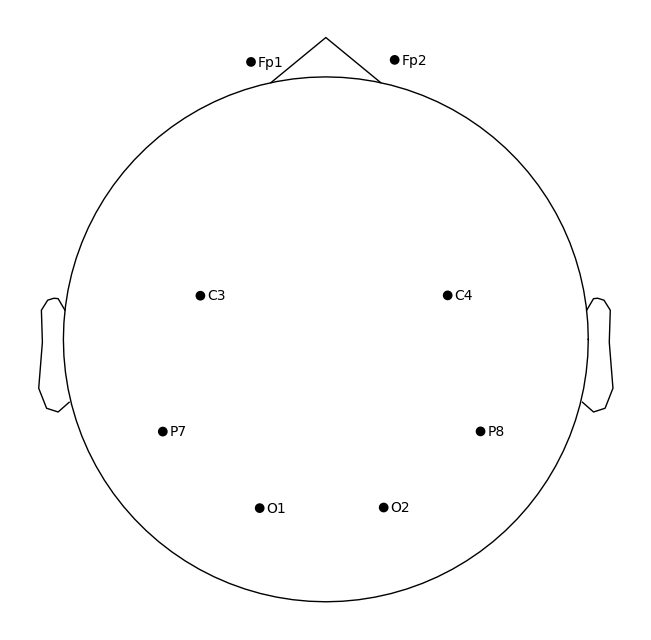

Fp1 [-0.031  0.115  0.028]
Fp2 [0.028 0.115 0.028]
C3 [-0.067  0.023  0.105]
C4 [0.065 0.024 0.104]
O1 [-0.032 -0.081  0.055]
O2 [ 0.028 -0.08   0.055]
P7 [-0.074 -0.042  0.041]
P8 [ 0.071 -0.042  0.041]


In [24]:
raw = mne.io.read_raw_fif(Path(ROOT_RAW_PATH,"ID6", "ID6_13-04-26_A_raw.fif"),preload=True)
montage = raw.get_montage()
#print(raw)
raw.plot_sensors(kind="topomap",show_names=True)


for ch in raw.ch_names:
  print(ch,np.round(montage.get_positions()["ch_pos"][ch],3))

#**CURRENT DATA**

In [26]:
#@title Look for current data
def get_useful_sessions():
  total_useful_sessions = 0
  for id in get_subjects():
    df_all = pd.read_csv(Path(ROOT_DATASETS,"all_ids.csv"))
    df_all = df_all[df_all["ID"]==id]
    df_all = df_all[df_all["COMPANY"] == "BitBrain_EEG"]
    print(f"ID{id}: {Counter(df_all["LABEL"])}")
    total_useful_sessions = total_useful_sessions + df_all.shape[0]
  print(f"Total Useful Sessions:{total_useful_sessions}")

get_useful_sessions()

ID2: Counter({'B': 7, 'A': 4})
ID5: Counter({'B': 6, 'A': 4})
ID6: Counter({'B': 10})
ID8: Counter({'B': 9, 'A': 5})
ID10: Counter({'B': 10, 'A': 6})
ID13: Counter({'B': 12, 'A': 3})
Total Useful Sessions:76


In [27]:
#@title Save only Bitbrain Sessions
def get_all_df_bitbrain():
  df_all = pd.read_csv(Path(ROOT_DATASETS,"all_ids.csv"))
  df_all = df_all[df_all["COMPANY"] == "BitBrain_EEG"]
  df_all = df_all.reset_index(drop = True)
  #df_all = df_all[["RAW EEG", "TRIMMED RAW EEG", "PSYCHOPY", "LABEL", "DATE", "COMPANY", "ID"]]
  #display(df_all)
  return df_all
df_final = get_all_df_bitbrain()
df_final.to_csv(Path(ROOT_DATASETS, "Bitbrain_eeg_sessions.csv"), index = False)

In [28]:
def get_eeg_sessions(id):
  df_all = get_all_df_bitbrain()
  df_all = df_all[df_all["ID"]==id]
  print(f"ID{id}: {Counter(df_all["LABEL"])}")
  display(df_all)
get_eeg_sessions(id = 10)

ID10: Counter({'B': 10, 'A': 6})


,RAW EEG,TRIMMED RAW EEG,PSYCHOPY,LABEL,DATE,COMPANY,ID,ICA PATH,ICA EXCLUDE,BAD CHANNELS
45,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,18-05-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
46,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,21-05-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
47,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,26-05-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
48,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,28-05-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,1.0,NaN
49,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,02-06-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
50,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,A,04-06-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
51,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,05-06-26,BitBrain_EEG,10,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN
52,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,10-06-26,BitBrain_EEG,10,NaN,NaN,NaN
53,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,08-06-26,BitBrain_EEG,10,NaN,NaN,NaN
54,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,12-06-26,BitBrain_EEG,10,NaN,NaN,NaN


In [30]:
old_df = pd.read_csv(Path(ROOT_DATASETS, "Bitbrain_eeg_sessions.csv"))
print(old_df.columns.tolist())

['RAW EEG', 'TRIMMED RAW EEG', 'PSYCHOPY', 'LABEL', 'DATE', 'COMPANY', 'ID', 'ICA PATH', 'ICA EXCLUDE', 'BAD CHANNELS', 'MNE PATH']


In [36]:
#@title UPDATE MY NEW SESSIONS
def update_bitbrain_sessions():
    old_file = Path(ROOT_DATASETS, "Bitbrain_eeg_sessions.csv")
    new_df = (
        pd.read_csv(Path(ROOT_DATASETS, "all_ids.csv"))
        .query("COMPANY == 'BitBrain_EEG'")
        .reset_index(drop=True)
    )
    if not old_file.exists():
        new_df.to_csv(old_file, index=False)
        return new_df

    old_df = pd.read_csv(old_file)
    keys = ["ID", "DATE", "LABEL"]

    old_keys = set(map(tuple, old_df[keys].values))
    new_sessions = new_df[
        ~new_df[keys].apply(tuple, axis=1).isin(old_keys)
    ].copy()

    for col in old_df.columns:
        if col not in new_sessions.columns:
            new_sessions[col] = pd.NA
    new_sessions = new_sessions[old_df.columns]
    final_df = pd.concat([old_df, new_sessions], ignore_index=True)
    final_df.to_csv(old_file, index=False)

    return final_df


df_final = update_bitbrain_sessions()
display(df_final)

,RAW EEG,TRIMMED RAW EEG,PSYCHOPY,LABEL,DATE,COMPANY,ID,ICA PATH,ICA EXCLUDE,BAD CHANNELS,MNE PATH
0,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,A,11-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN,G:\Mon Drive\M2_Project_Master\Data\Participan...
1,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,A,19-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,0.0,NaN,G:\Mon Drive\M2_Project_Master\Data\Participan...
2,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,A,22-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,1.0,NaN,G:\Mon Drive\M2_Project_Master\Data\Participan...
3,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,A,27-05-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,0,"AF7,P8",G:\Mon Drive\M2_Project_Master\Data\Participan...
4,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,G:/Mon Drive/M2_Project_Master/Data/Participan...,B,08-06-26,BitBrain_EEG,2,G:\Mon Drive\M2_Project_Master\Data\Participan...,"2,4",NaN,G:\Mon Drive\M2_Project_Master\Data\Participan...
...,...,...,...,...,...,...,...,...,...,...,...
71,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,24-06-26,BitBrain_EEG,10,NaN,NaN,NaN,NaN
72,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,26-06-26,BitBrain_EEG,10,NaN,NaN,NaN,NaN
73,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,19-06-26,BitBrain_EEG,13,NaN,NaN,NaN,NaN
74,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,/content/drive/My Drive/M2_Project_Master/Data...,B,22-06-26,BitBrain_EEG,13,NaN,NaN,NaN,NaN
